**Import Advance Python Libraries**


In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np
import warnings
import re
from collections import Counter

warnings.filterwarnings('ignore')

**Style**

In [29]:
sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 150,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family": "DejaVu Sans",
})

PALETTE = ["#3B82F6","#10B981","#F59E0B","#EF4444","#8B5CF6",
           "#EC4899","#14B8A6","#F97316","#6366F1","#84CC16"]


**Load Data**

In [30]:
df= pd.read_pickle("clean_data2.pkl")

In [31]:
df.head()

,show_id,type,title,director,country,language,date_added,release_year,imdb_rating,duration,listed_in
0,s0001,TV Show,Stranger Things 1,Unknown,Not Specified,Not Specified,2024-03-13,2016,7.8,114.0,Documentaries
1,s0002,TV Show,The Crown 2,Peter Morgan,United States,English,2025-04-14,2016,8.6,25.0,Thrillers
2,s0003,TV Show,Money Heist 3,Álex Pina,Spain,Spanish,2017-05-20,2017,8.2,30.0,"Sci-Fi, Fantasy"
3,s0004,TV Show,Dark 4,"Baran bo Odar, Jantje Friese",Germany,German,2017-04-28,2017,8.7,35.0,Documentaries
4,s0005,TV Show,Breaking Bad 5,Vince Gilligan,United States,English,2023-08-20,2008,9.5,40.0,International Movies


In [32]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
country,0
language,0
date_added,0
release_year,0
imdb_rating,0
duration,0


In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 496 entries, 0 to 499
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       496 non-null    object        
 1   type          496 non-null    object        
 2   title         496 non-null    object        
 3   director      496 non-null    object        
 4   country       496 non-null    object        
 5   language      496 non-null    object        
 6   date_added    496 non-null    datetime64[ns]
 7   release_year  496 non-null    int64         
 8   imdb_rating   496 non-null    float64       
 9   duration      496 non-null    float64       
 10  listed_in     496 non-null    object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(7)
memory usage: 46.5+ KB


In [34]:
df.shape

(496, 11)

**STEP 1 - DATASET OVERVIEW**

STEP 1 – Dataset Overview


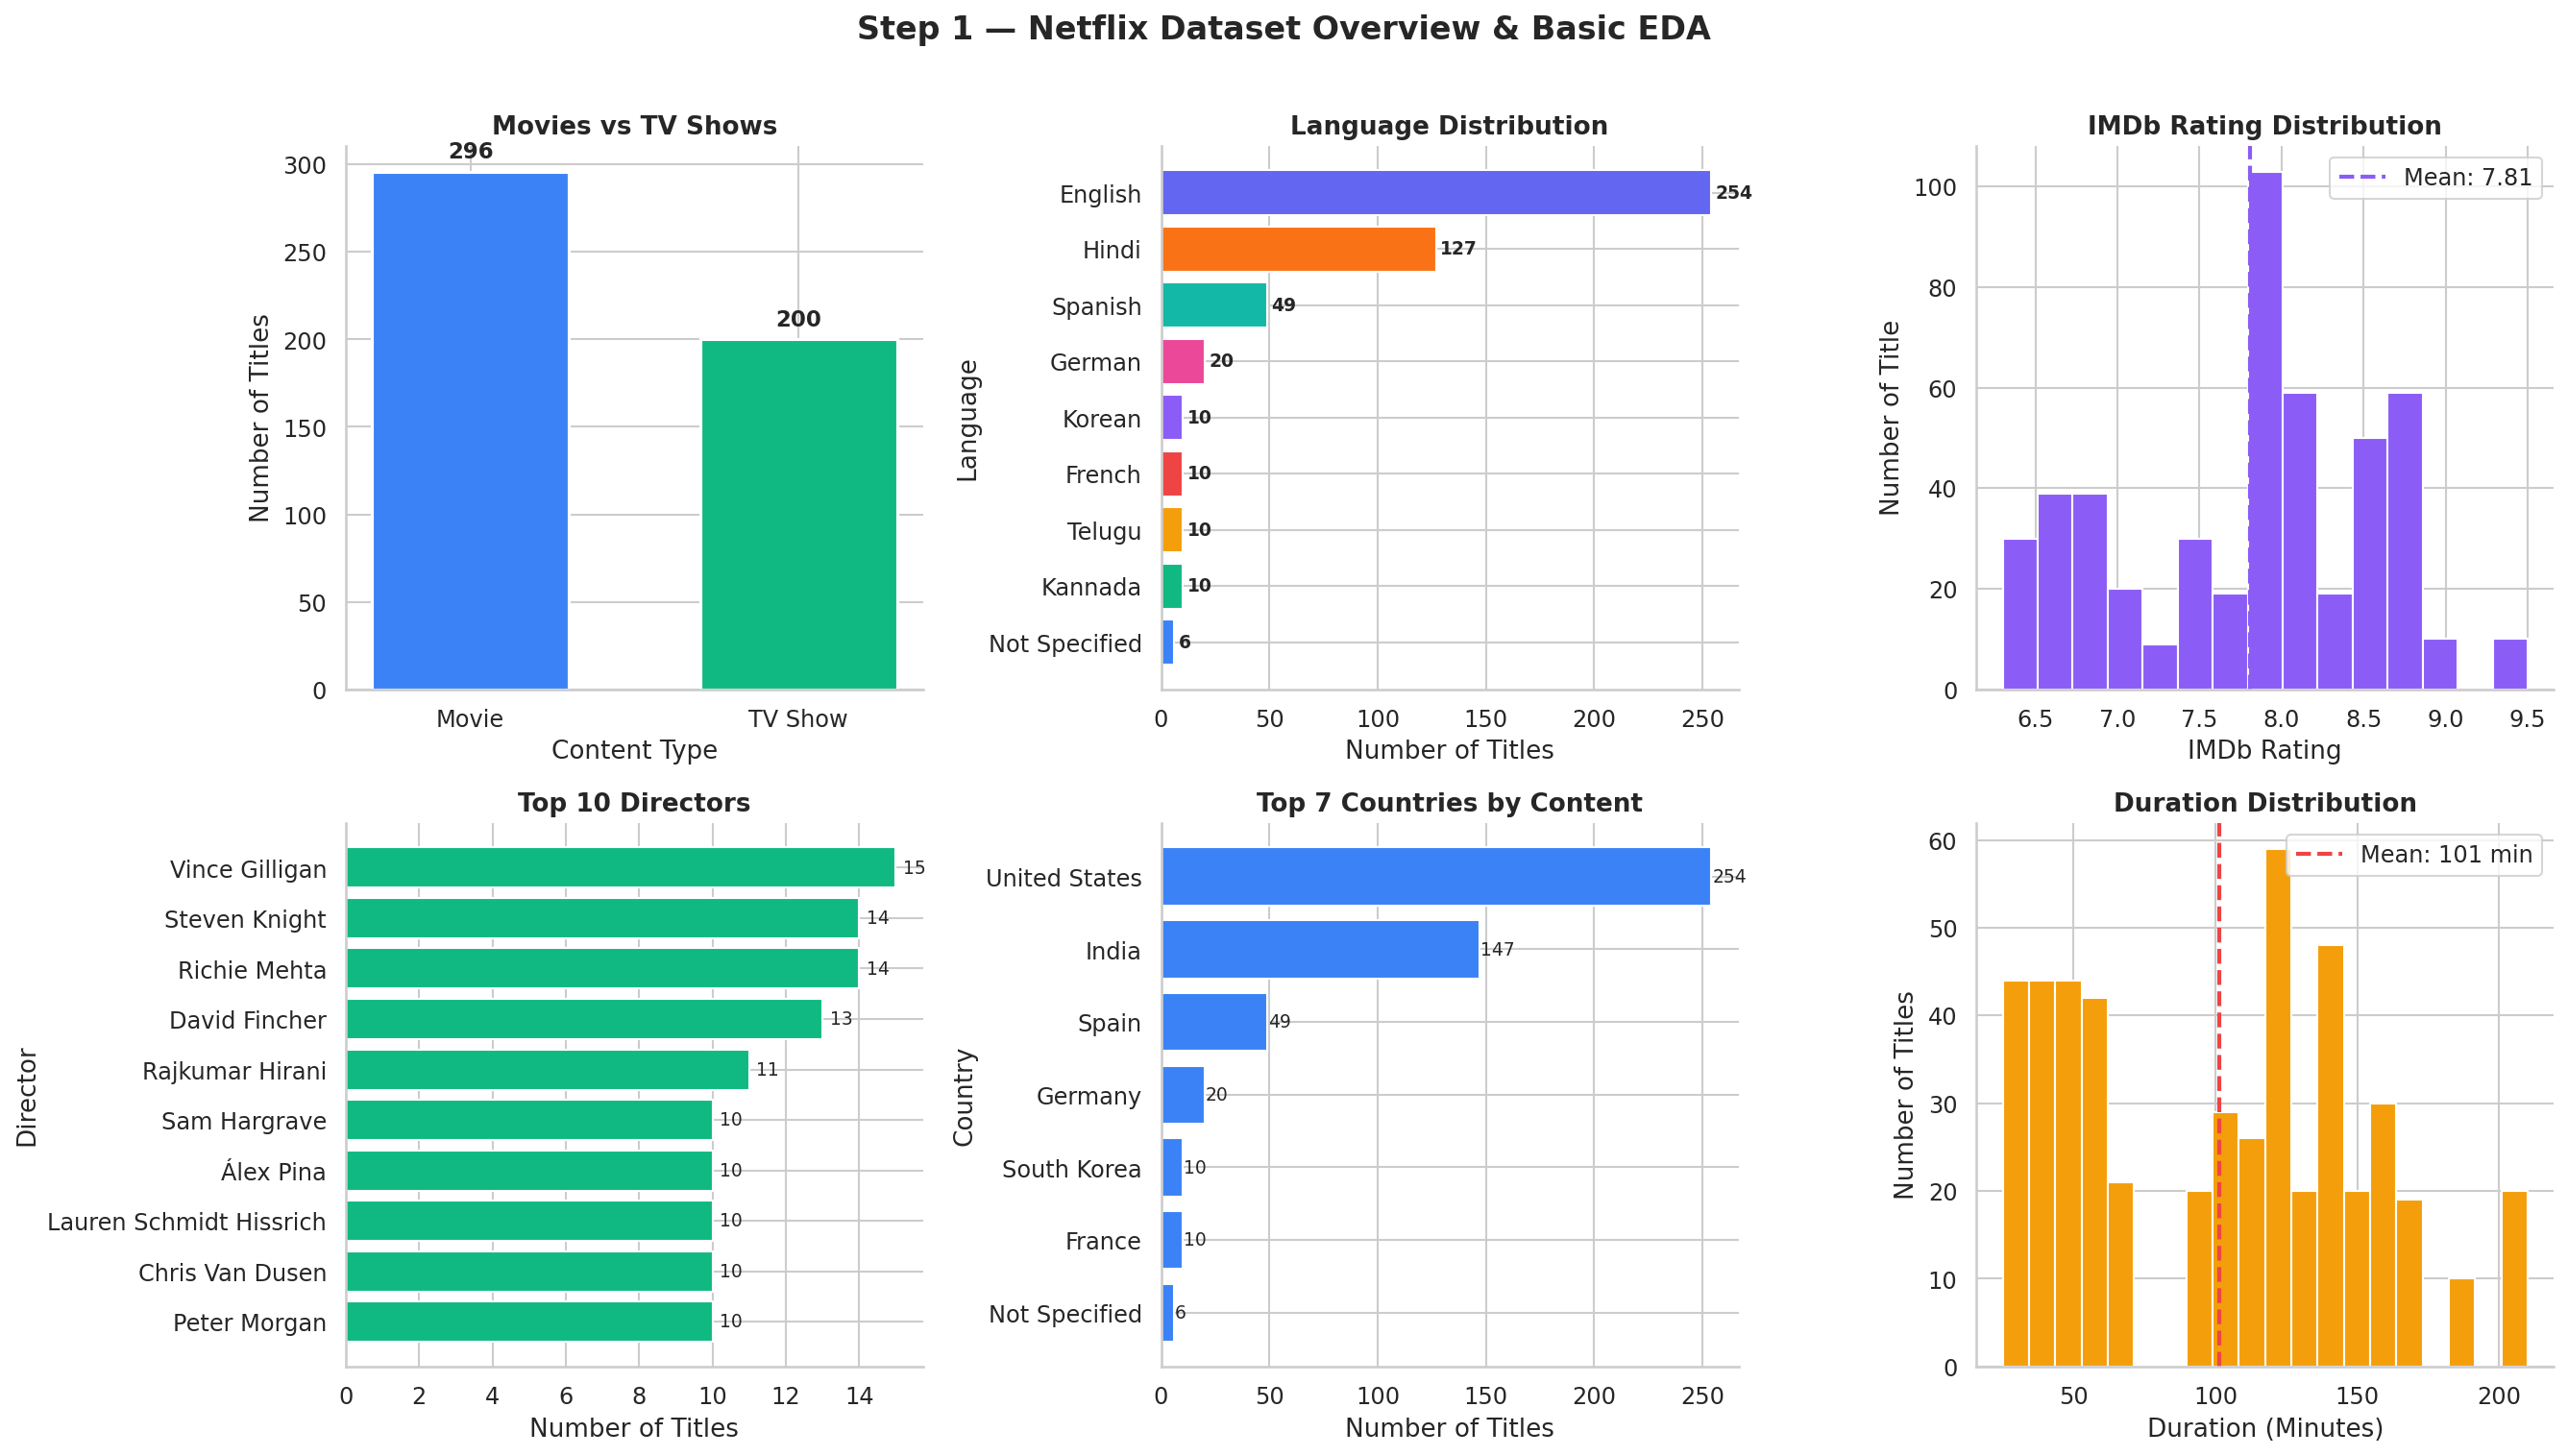

In [41]:
from matplotlib.typing import LineStyleType
print("STEP 1 – Dataset Overview")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle(
    "Step 1 — Netflix Dataset Overview & Basic EDA",
    fontsize=16,
    fontweight="bold",
    y=1.01
)

### 1a - Movies vs tv show
ax = axes[0,0]

counts = df['type'].value_counts()

bars = ax.bar(
    counts.index,
    counts.values,
    color=PALETTE[:2],
    edgecolor="white",
    linewidth=1.5,
    width=0.6
)

for b in bars:
    ax.text(
        b.get_x() + b.get_width()/2,
        b.get_height() + 5,
        str(int(b.get_height())),
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

ax.set_title("Movies vs TV Shows", fontweight="bold")
ax.set_xlabel("Content Type")
ax.set_ylabel("Number of Titles")




### 1b - Language Distribution


ax = axes[0, 1]

lang = df["language"].value_counts().sort_values()

bars = ax.barh(
    lang.index,
    lang.values,
    color=PALETTE[:len(lang)],
    edgecolor="white"
)

for bar in bars:
    ax.text(
        bar.get_width() + 2,
        bar.get_y() + bar.get_height() / 2,
        str(int(bar.get_width())),
        va="center",
        fontsize=9,
        fontweight="bold"
    )

ax.set_title("Language Distribution", fontweight="bold")
ax.set_xlabel("Number of Titles")
ax.set_ylabel("Language")


### 1c - IMDb Rating Distribution ###

ax = axes[0,2]

ax.hist(
    df['imdb_rating'],
    bins=15,
    color=PALETTE[4],
    edgecolor="white",
    linewidth=1
)

ax.axvline(
    df["imdb_rating"].mean(),
    color=PALETTE[4],
    linestyle="--",
    linewidth=2,
    label=f'Mean: {df["imdb_rating"].mean():.2f}'
)

ax.set_title("IMDb Rating Distribution", fontweight="bold")
ax.set_xlabel("IMDb Rating")
ax.set_ylabel("Number of Title")
ax.legend()


### 1d Top 10 Director ###

ax = axes[1,0]

top_directors = df['director'].value_counts().head(10)

bars = ax.barh(
    top_directors.index[::-1],
    top_directors.values[::-1],
    color=PALETTE[1],
    edgecolor="white"
)

for bar in bars:
    ax.text(
        bar.get_width() + 0.2,
        bar.get_y() + bar.get_height() / 2,
        str(int(bar.get_width())),
        va="center",
        fontsize=9
    )

ax.set_title("Top 10 Directors", fontweight="bold")
ax.set_xlabel("Number of Titles")
ax.set_ylabel("Director")



### 1f - Content by country

ax = axes[1,1]

top_countries = df['country'].value_counts().head(7)

bars = ax.barh(
    top_countries.index[::-1],
    top_countries.values[::-1],
    color=PALETTE[0],
    edgecolor="white"
)

for bar in bars:
  ax.text(
      bar.get_width() + 0.5,
      bar.get_y() + bar.get_height() /2,
      str(int(bar.get_width())),
      va="center",
      fontsize=9
  )

ax.set_title("Top 7 Countries by Content", fontweight="bold")
ax.set_xlabel("Number of Titles")
ax.set_ylabel("Country")


### 1f - Duration Disstribution   ###

ax = axes[1, 2]

ax.hist(
    df["duration"],
    bins=20,
    color=PALETTE[2],
    edgecolor="white",
    linewidth=1
)

ax.axvline(
    df["duration"].mean(),
    color=PALETTE[3],
    linestyle="--",
    linewidth=2,
    label=f'Mean: {df["duration"].mean():.0f} min'
)

ax.set_title("Duration Distribution", fontweight="bold")
ax.set_xlabel("Duration (Minutes)")
ax.set_ylabel("Number of Titles")
ax.legend()


plt.tight_layout()

plt.savefig("step1_overview.png", bbox_inches="tight")

plt.show()
plt.close()

**STEP 2 - CONTENT ANALYSIS**

STEP 2 – Content Analysis


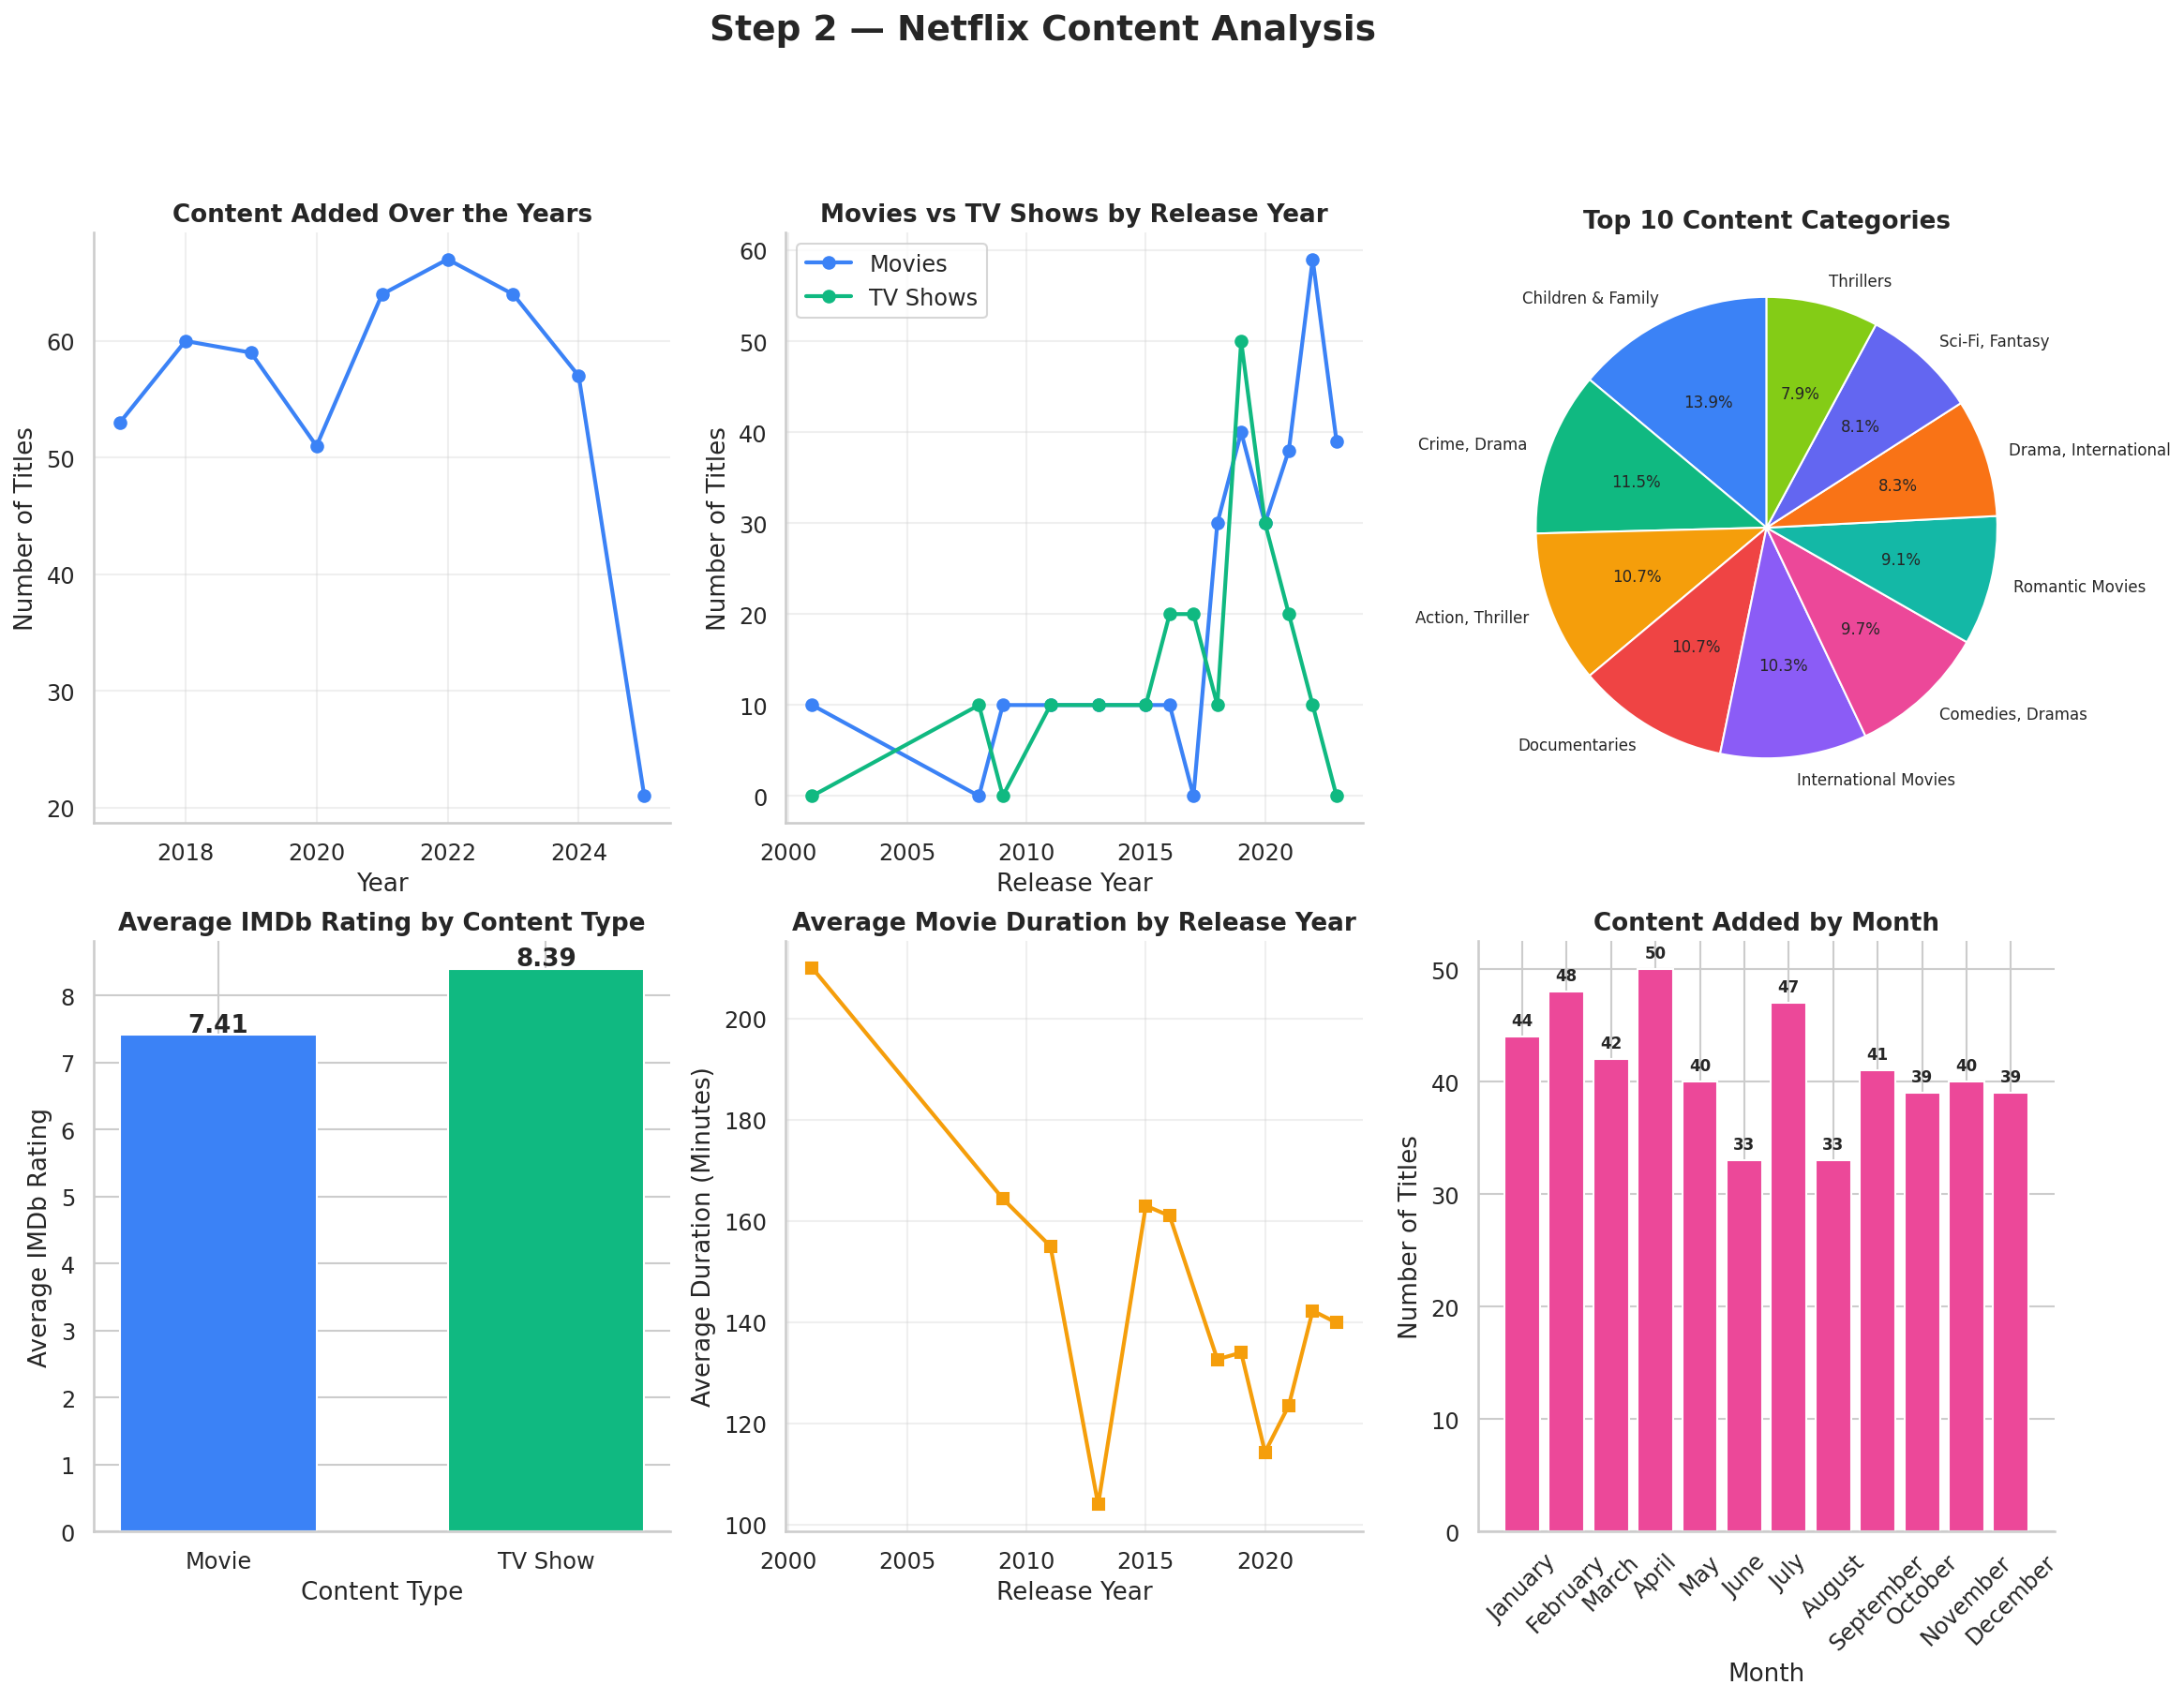

In [64]:
from matplotlib import colors
print("STEP 2 – Content Analysis")

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

fig.suptitle(
    "Step 2 — Netflix Content Analysis",
    fontsize=18,
    fontweight="bold",
    y=1.01
)

# 2a - Content Added Over the Years

ax = axes[0, 0]

content_by_year = df['date_added'].dt.year.value_counts().sort_index()

ax.plot(
    content_by_year.index,
    content_by_year.values,
    marker='o',
    linewidth=2,
    color=PALETTE[0]
)

ax.set_title("Content Added Over the Years", fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Number of Titles")
ax.grid(True, alpha=0.3)


# 2b - Movies vs TV Shows by Release Year

ax = axes[0, 1]

content_by_year = df.groupby(
    ['release_year', 'type']
).size().unstack(fill_value=0)

ax.plot(
    content_by_year.index,
    content_by_year['Movie'],
    marker='o',
    linewidth=2,
    label='Movies',
    color=PALETTE[0]
)

ax.plot(
    content_by_year.index,
    content_by_year['TV Show'],
    marker='o',
    linewidth=2,
    label='TV Shows',
    color=PALETTE[1]
)

ax.set_title("Movies vs TV Shows by Release Year", fontweight="bold")
ax.set_xlabel("Release Year")
ax.set_ylabel("Number of Titles")
ax.legend()
ax.grid(True, alpha=0.3)



# 2c - Top 10 Content Categories

ax = axes[0, 2]

top_categories = df['listed_in'].value_counts().head(10)

ax.pie(
    top_categories.values,
    labels=top_categories.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=PALETTE[:10],
    textprops={'fontsize': 8}
)

ax.set_title("Top 10 Content Categories", fontweight="bold")



# 2d - Average IMDb Rating by Content Type

ax = axes[1, 0]

avg_rating = df.groupby('type')['imdb_rating'].mean()

bars = ax.bar(
    avg_rating.index,
    avg_rating.values,
    color=PALETTE[:2],
    edgecolor="white",
    width=0.6
)

for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.05,
        f"{bar.get_height():.2f}",
        ha="center",
        fontweight="bold"
    )

ax.set_title("Average IMDb Rating by Content Type", fontweight="bold")
ax.set_xlabel("Content Type")
ax.set_ylabel("Average IMDb Rating")


### 2e - Average Movie Duration By Release Year

ax = axes[1,1]

movie_duration = (
    df[df['type'] == 'Movie']
    .groupby('release_year')['duration']
    .mean()
)

ax.plot(
    movie_duration.index,
    movie_duration.values,
    marker='s',
    linewidth=2,
    color=PALETTE[2]
)

ax.set_title(
    "Average Movie Duration by Release Year",
    fontweight="bold"
)

ax.set_xlabel("Release Year")
ax.set_ylabel("Average Duration (Minutes)")
ax.grid(True, alpha=0.3)


### 2f - Content Added By Month

ax = axes[1,2]

content_by_month = df['date_added'].dt.month_name().value_counts()

months_order = [
    'January', 'February', 'March', 'April',
    'May', 'June', 'July', 'August',
    'September', 'October', 'November', 'December'
]

content_by_month = content_by_month.reindex(months_order)

bars = ax.bar(
    content_by_month.index,
    content_by_month.values,
    color=PALETTE[5],
    edgecolor="white"
)

for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        str(int(bar.get_height())),
        ha="center",
        fontsize=8,
        fontweight="bold"
    )

ax.set_title("Content Added by Month", fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Number of Titles")

ax.tick_params(axis='x', rotation=45)

plt.savefig("step2_Content_Analysis.png", bbox_inches="tight")


**STEP 3 - RELEATIONSHIP ANALYSIS**

STEP 3 – Relationship Analysis


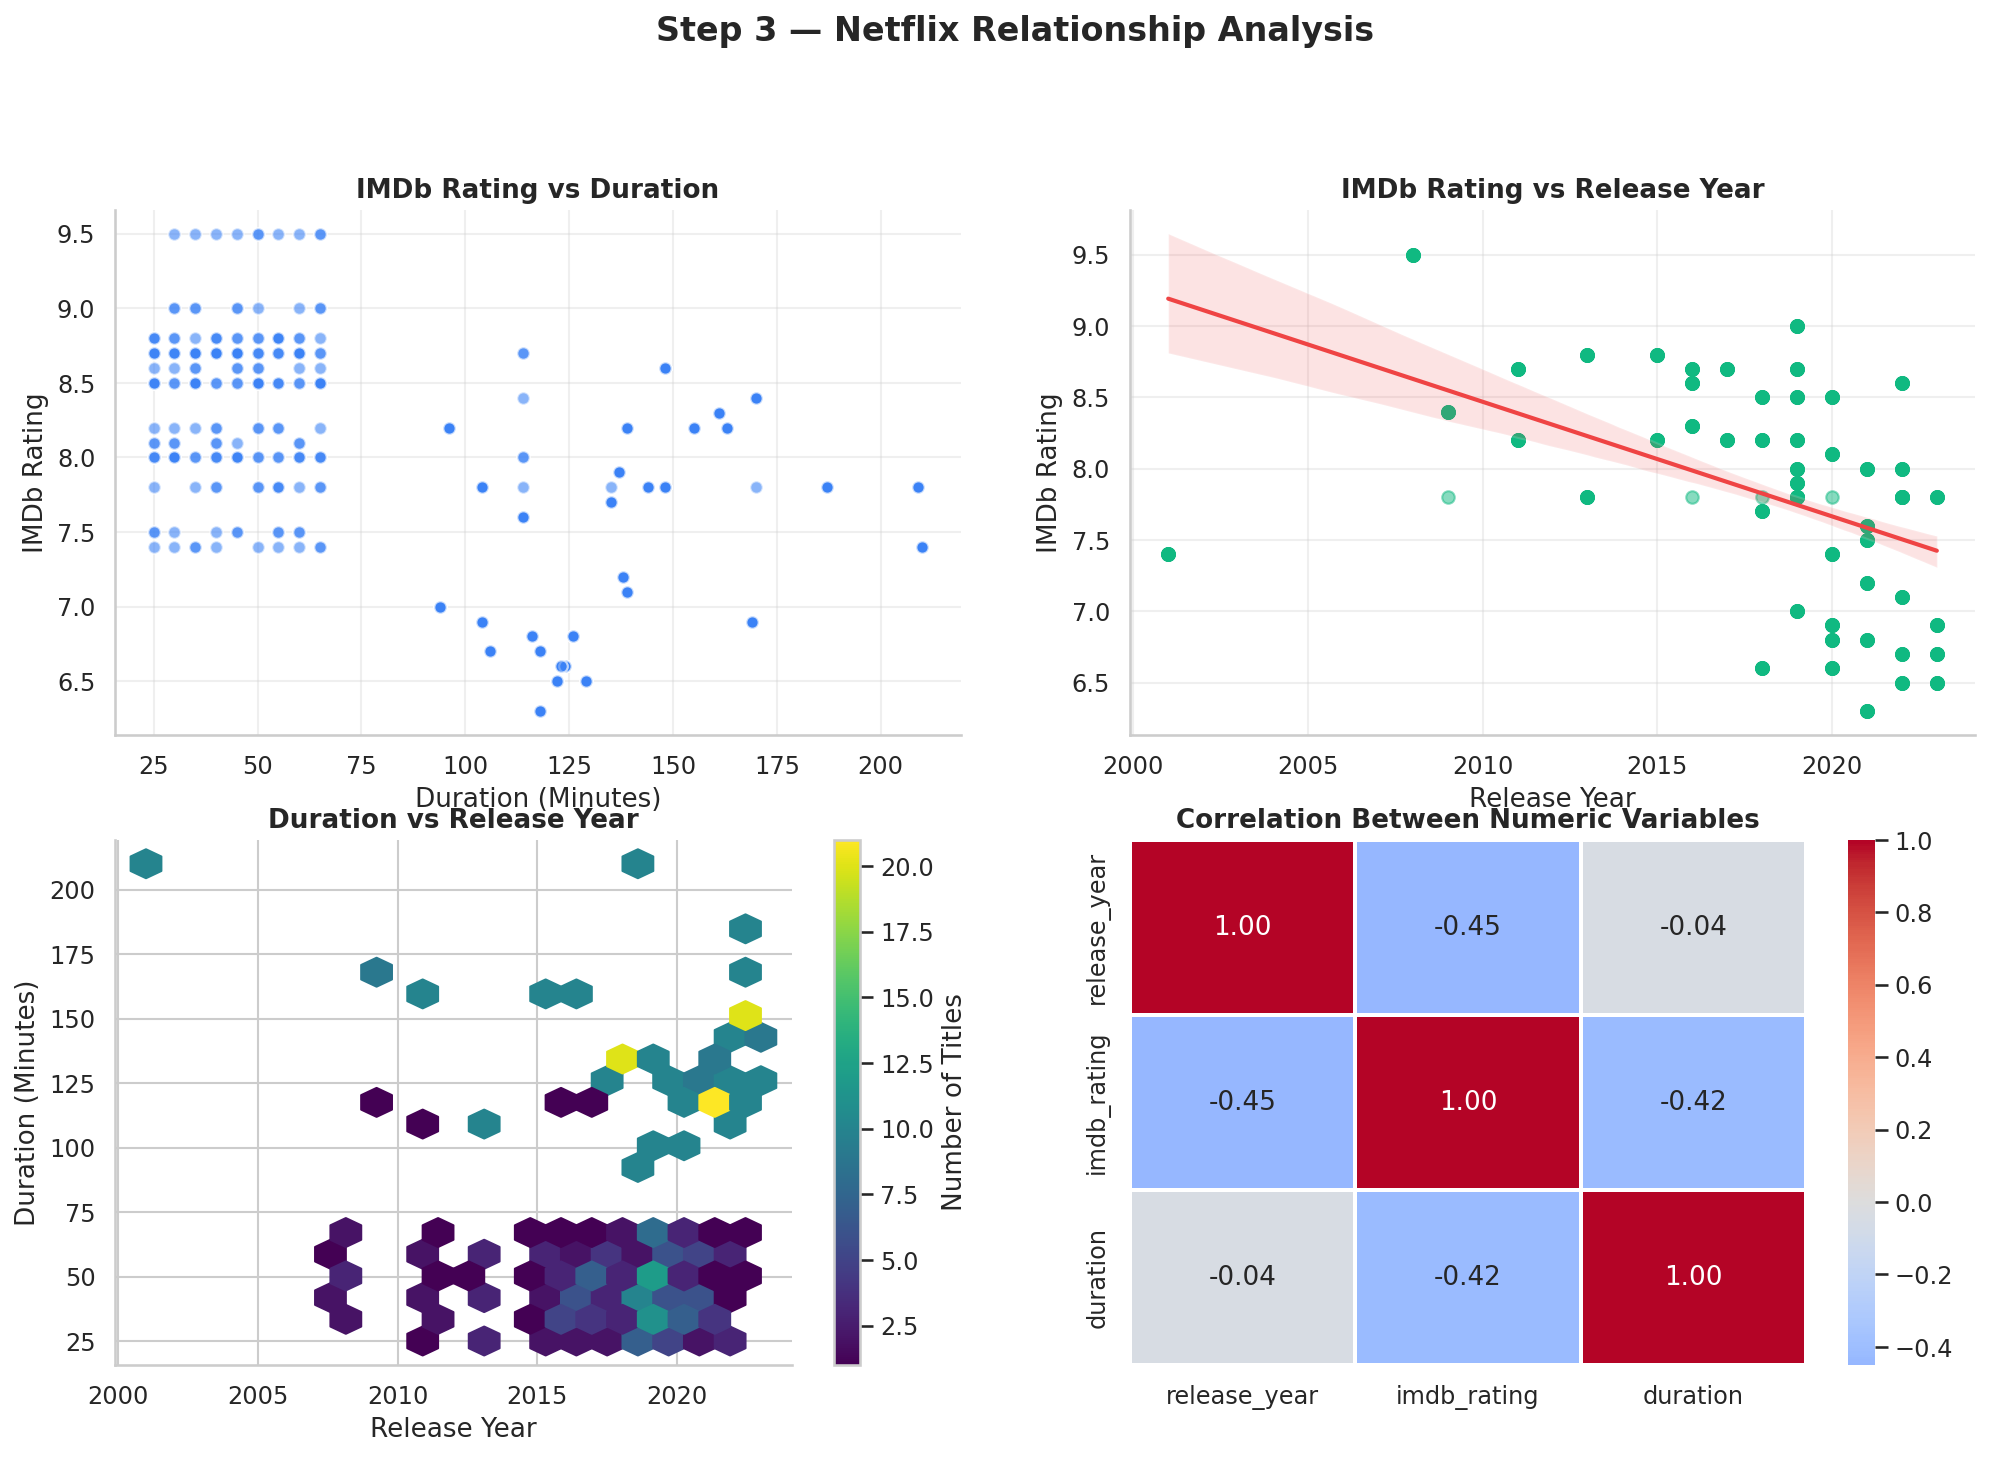

In [77]:
print("STEP 3 – Relationship Analysis")

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

fig.suptitle(
    "Step 3 — Netflix Relationship Analysis",
    fontsize=16,
    fontweight="bold",
    y=1.01
)

# 3a - IMDb Rating vs Duration

ax = axes[0, 0]

ax.scatter(
    df["duration"],
    df["imdb_rating"],
    alpha=0.6,
    color=PALETTE[0],
    edgecolor="white"
)

ax.set_title(
    "IMDb Rating vs Duration",
    fontweight="bold"
)

ax.set_xlabel("Duration (Minutes)")
ax.set_ylabel("IMDb Rating")

ax.grid(True, alpha=0.3)



# 3b - IMDb Rating vs Release Year

ax = axes[0, 1]

sns.regplot(
    data=df,
    x="release_year",
    y="imdb_rating",
    scatter_kws={
        "alpha": 0.5,
        "color": PALETTE[1]
    },
    line_kws={
        "color": PALETTE[3],
        "linewidth": 2
    },
    ax=ax
)

ax.set_title(
    "IMDb Rating vs Release Year",
    fontweight="bold"
)

ax.set_xlabel("Release Year")
ax.set_ylabel("IMDb Rating")

ax.grid(True, alpha=0.3)




# 3c - Duration vs Release Year

ax = axes[1, 0]

hb = ax.hexbin(
    df["release_year"],
    df["duration"],
    gridsize=20,
    cmap="viridis",
    mincnt=1
)

fig.colorbar(
    hb,
    ax=ax,
    label="Number of Titles"
)

ax.set_title(
    "Duration vs Release Year",
    fontweight="bold"
)

ax.set_xlabel("Release Year")
ax.set_ylabel("Duration (Minutes)")



# 3d - Correlation Heatmap

ax = axes[1, 1]

corr = df[
    ["release_year", "imdb_rating", "duration"]
].corr()

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=1,
    ax=ax
)

ax.set_title(
    "Correlation Between Numeric Variables",
    fontweight="bold"
)

plt.savefig("step3_Releationship_Analysis.png", bbox_inches="tight")

**STEP 4- STATISTICAL & DISTRIBUTION ANALYSIS**

STEP 4 – Statistical & Distribution Analysis


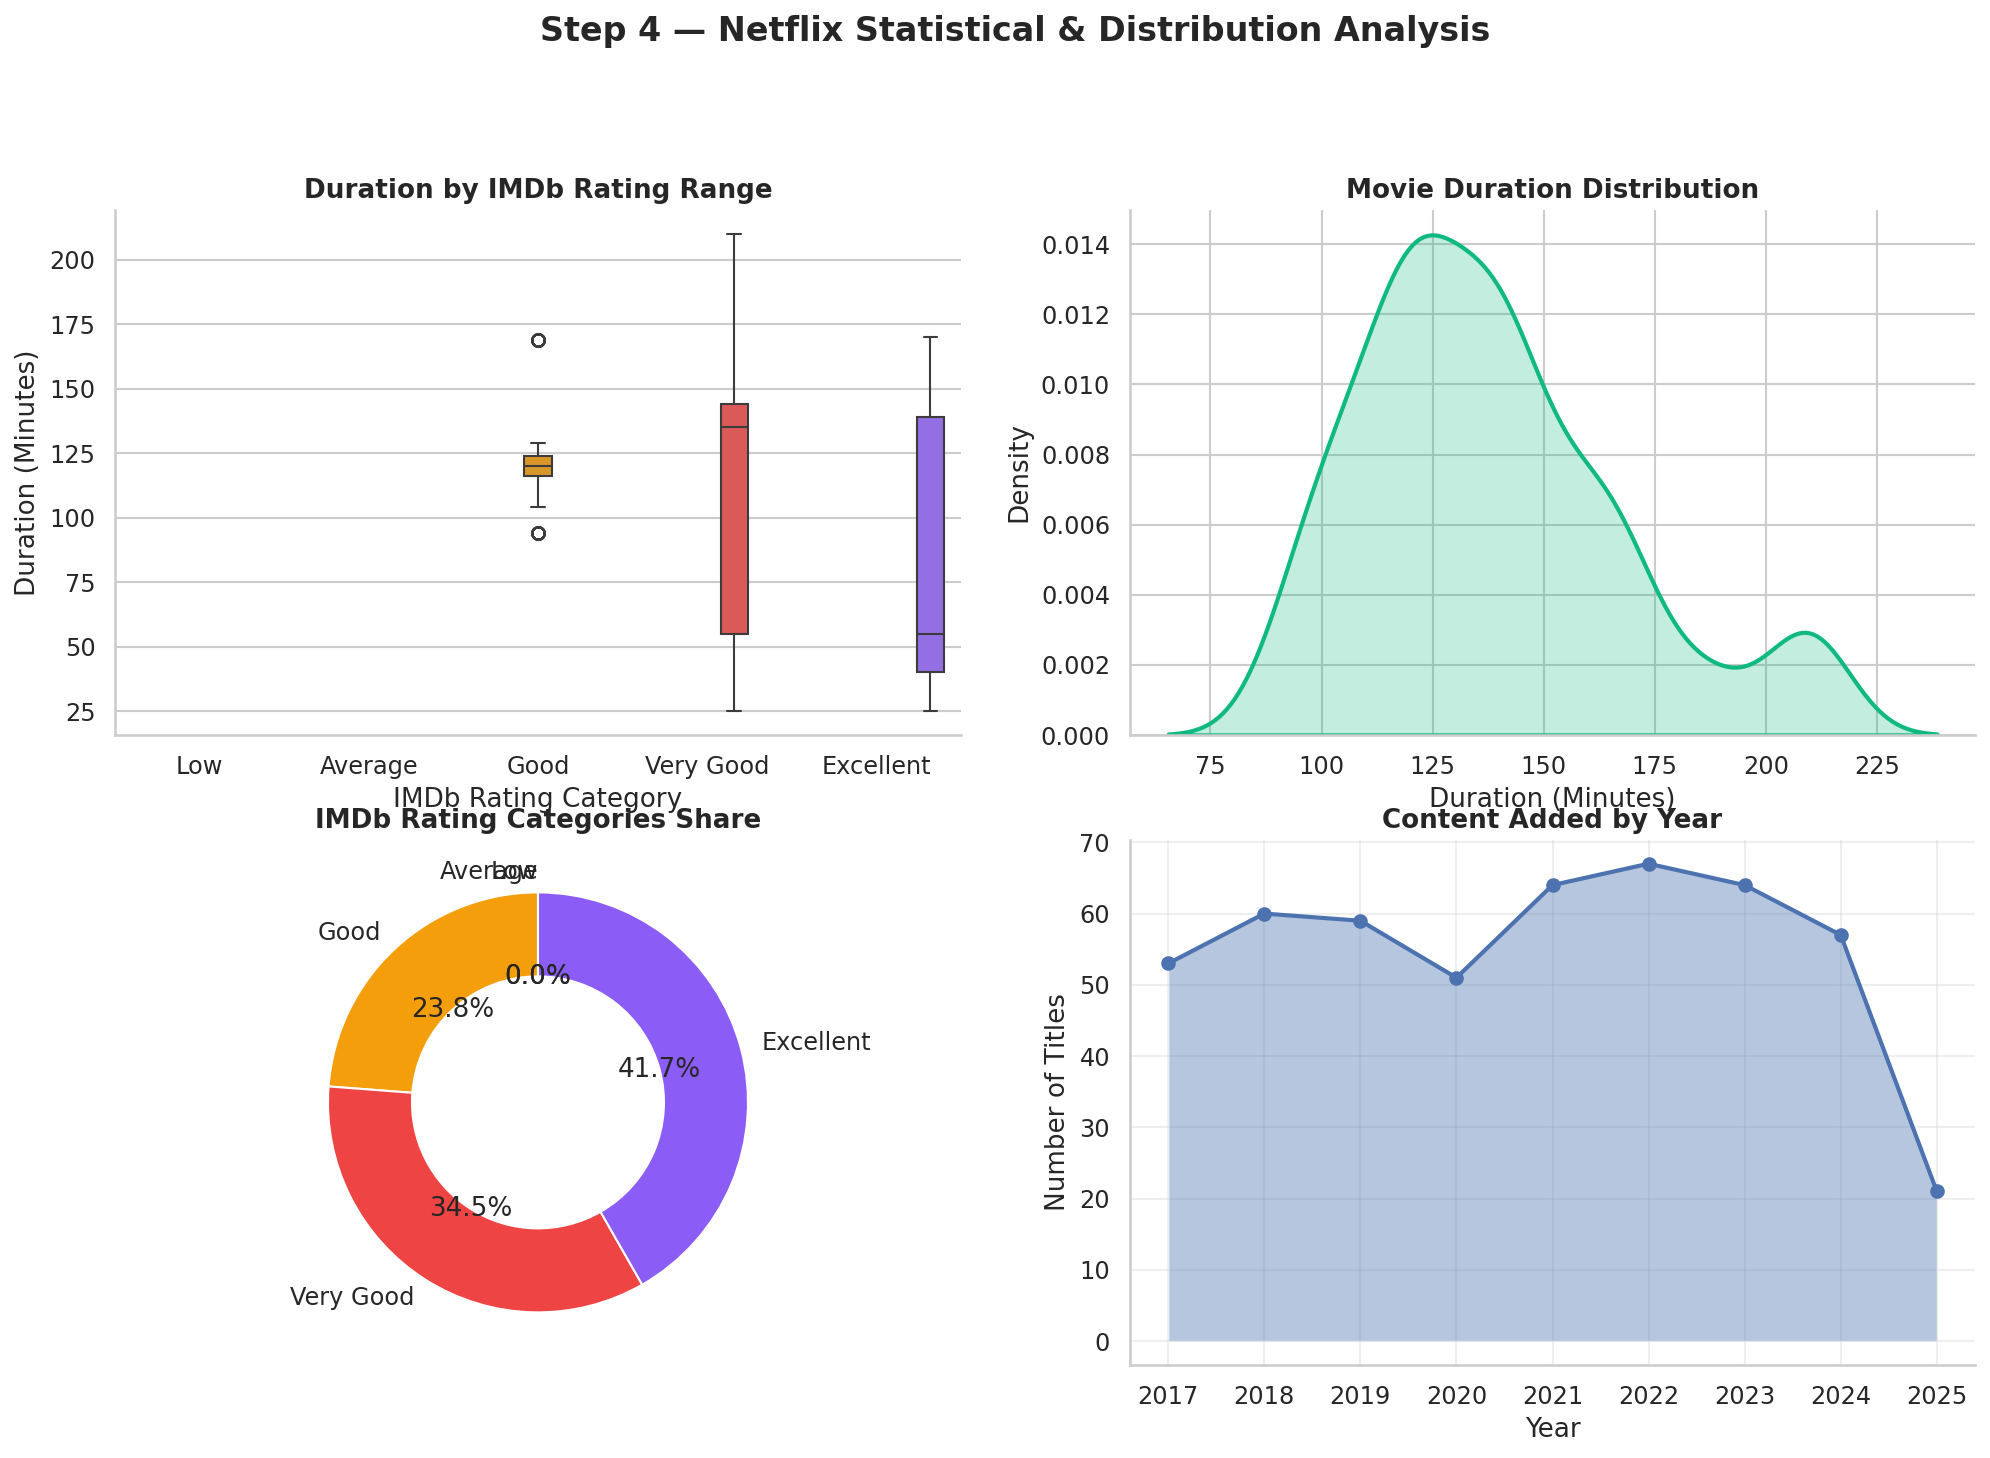

In [78]:
print("STEP 4 – Statistical & Distribution Analysis")

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

fig.suptitle(
    "Step 4 — Netflix Statistical & Distribution Analysis",
    fontsize=16,
    fontweight="bold",
    y=1.01
)


# Create IMDb rating categories

df["rating_category"] = pd.cut(
    df["imdb_rating"],
    bins=[0, 5, 6, 7, 8, 10],
    labels=["Low", "Average", "Good", "Very Good", "Excellent"]
)

# 4a - Duration by IMDb Rating Range

ax = axes[0, 0]

sns.boxplot(
    data=df,
    x="rating_category",
    y="duration",
    hue="rating_category",
    palette=PALETTE[:5],
    legend=False,
    ax=ax
)

ax.set_title(
    "Duration by IMDb Rating Range",
    fontweight="bold"
)

ax.set_xlabel("IMDb Rating Category")
ax.set_ylabel("Duration (Minutes)")



# 4b - Movie Duration Distribution

ax = axes[0, 1]

sns.kdeplot(
    data=df[df["type"] == "Movie"],
    x="duration",
    fill=True,
    color=PALETTE[1],
    linewidth=2,
    ax=ax
)

ax.set_title(
    "Movie Duration Distribution",
    fontweight="bold"
)

ax.set_xlabel("Duration (Minutes)")
ax.set_ylabel("Density")



### 4c - IMDb Rating Categories Share

rating_categories = pd.cut(
    df["imdb_rating"],
    bins=[0, 5, 6, 7, 8, 10],
    labels=["Low", "Average", "Good", "Very Good", "Excellent"]
)

rating_counts = rating_categories.value_counts().sort_index()

ax = axes[1, 0]

ax.pie(
    rating_counts.values,
    labels=rating_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=PALETTE[:5],
    wedgeprops={"width": 0.4, "edgecolor": "white"}
)

ax.set_title(
    "IMDb Rating Categories Share",
    fontweight="bold"
)




# 4d - Content Added by Year

content_by_year = df["date_added"].dt.year.value_counts().sort_index()

ax = axes[1, 1]

ax.fill_between(
    content_by_year.index,
    content_by_year.values,
    alpha=0.4
)

ax.plot(
    content_by_year.index,
    content_by_year.values,
    marker="o",
    linewidth=2
)

ax.set_title(
    "Content Added by Year",
    fontweight="bold"
)

ax.set_xlabel("Year")
ax.set_ylabel("Number of Titles")

ax.grid(True, alpha=0.3)


plt.savefig("step4_Statistical_Analysis.png", bbox_inches="tight")